In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

In [2]:
df=pd.read_csv('D:\B3_92\Datasets\car data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [5]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [6]:
df.duplicated().sum()

2

In [7]:
df=df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

In [10]:
df=df.drop('Car_Name',axis=1)

In [11]:
df['Year']=2025-df['Year']

In [12]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,11,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,12,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,8,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,14,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,11,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
296,9,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,10,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,16,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,8,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [13]:
df=pd.get_dummies(df,drop_first=True)

In [14]:
df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,11,3.35,5.59,27000,0,0,1,0,1
1,12,4.75,9.54,43000,0,1,0,0,1
2,8,7.25,9.85,6900,0,0,1,0,1
3,14,2.85,4.15,5200,0,0,1,0,1
4,11,4.60,6.87,42450,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...
296,9,9.50,11.60,33988,0,1,0,0,1
297,10,4.00,5.90,60000,0,0,1,0,1
298,16,3.35,11.00,87934,0,0,1,0,1
299,8,11.50,12.50,9000,0,1,0,0,1


In [15]:
y=df['Selling_Price']
x=df.drop('Selling_Price',axis=1)

In [16]:
print(x.shape)
print(y.shape)

(299, 8)
(299,)


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(239, 8)
(60, 8)
(239,)
(60,)


In [20]:
print(x_train)
print(y_train)

     Year  Present_Price  Kms_Driven  Owner  Fuel_Type_Diesel  \
6      10           8.12       18796      0                 0   
185    17           0.58        1900      0                 0   
187    12           0.51       32000      0                 0   
148    15           0.94       45000      0                 0   
31     14           4.89       54200      0                 0   
..    ...            ...         ...    ...               ...   
190    17           0.75       60000      0                 0   
72     12          18.61       56001      0                 0   
108     9           1.50       18000      0                 0   
272    10          10.00       27600      0                 0   
104     8           1.47        4100      0                 0   

     Fuel_Type_Petrol  Seller_Type_Individual  Transmission_Manual  
6                   1                       0                    1  
185                 1                       1                    0  
187         

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
model=LinearRegression()

In [23]:
model.fit(x_train,y_train)

LinearRegression()

In [24]:
y_pred=model.predict(x_test)
print(y_pred)

[ 7.50192151  7.79152142  1.36644388  7.00941894 11.16328988  4.53410247
  8.49246345  1.70078181  8.82421963 -0.96348801 10.31444007 -0.97386896
  0.71832735  1.53711566  4.97622203  5.04627395  1.29503012  1.85159301
 21.56570817  0.86767992  0.93078859  2.45202839  5.58169747  0.2581242
  6.26649907  7.82350038  8.68226641  1.1746619   4.84357381  4.92069701
  3.26811058  5.48959967  6.27470319  2.75388094  2.90385159  6.96790194
  1.26406586 -4.97141242  1.38043678 10.38468561  7.10536052  9.04017934
  1.62741133  4.01521109  0.97463542 -2.14675103  8.1451697   4.37395524
  5.64880685 -0.59577608  0.66072164  0.20325682 10.20766115  9.45415687
  7.29949412  6.25536738  3.71408634  3.43110175  9.56341995  9.1600735 ]


In [25]:
model.coef_

array([-3.31040961e-01,  4.37186741e-01, -1.05181127e-05,  6.42855635e-01,
        2.13911103e+00,  6.90622132e-01, -1.30137688e+00, -1.57212521e+00])

In [26]:
model.intercept_

6.2987578823505315

In [27]:
x_test

,Year,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
283,9,11.800,9010,0,0,1,0,1
267,9,9.400,19434,0,1,0,0,1
166,9,0.550,1000,0,0,1,1,1
9,10,8.920,42367,0,1,0,0,1
78,15,22.830,80000,0,0,1,0,0
280,10,5.900,14465,0,0,1,0,1
95,13,18.610,72000,0,0,1,0,1
111,9,1.500,8700,0,0,1,1,1
5,7,9.830,2071,0,1,0,0,1
175,14,0.787,75000,0,0,1,1,1


In [28]:
y_pred

array([ 7.50192151,  7.79152142,  1.36644388,  7.00941894, 11.16328988,
        4.53410247,  8.49246345,  1.70078181,  8.82421963, -0.96348801,
       10.31444007, -0.97386896,  0.71832735,  1.53711566,  4.97622203,
        5.04627395,  1.29503012,  1.85159301, 21.56570817,  0.86767992,
        0.93078859,  2.45202839,  5.58169747,  0.2581242 ,  6.26649907,
        7.82350038,  8.68226641,  1.1746619 ,  4.84357381,  4.92069701,
        3.26811058,  5.48959967,  6.27470319,  2.75388094,  2.90385159,
        6.96790194,  1.26406586, -4.97141242,  1.38043678, 10.38468561,
        7.10536052,  9.04017934,  1.62741133,  4.01521109,  0.97463542,
       -2.14675103,  8.1451697 ,  4.37395524,  5.64880685, -0.59577608,
        0.66072164,  0.20325682, 10.20766115,  9.45415687,  7.29949412,
        6.25536738,  3.71408634,  3.43110175,  9.56341995,  9.1600735 ])

In [29]:
from sklearn.metrics import mean_squared_error,r2_score

In [30]:
mean_squared_error(y_pred,y_test)

6.3707529568281425

In [31]:
r2_score(y_pred,y_test)

0.6473866197527046

In [34]:
mse=[]
r2=[]

for i in range(1,101):
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)    
    model=LinearRegression()    
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
print(min(mse))
print(max(r2))

1.2372302599741476
0.9335655979279472


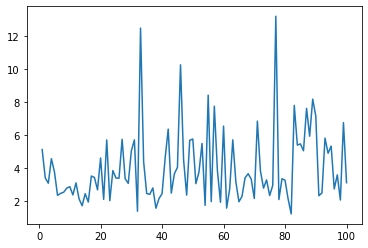

In [35]:
plt.plot(range(1,101),mse)
plt.show()

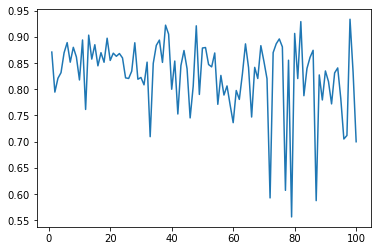

In [36]:
plt.plot(range(1,101),r2)
plt.show()

In [39]:
mse=[]
r2=[]
train_size=[0.5,0.6,0.7,0.8,0.9]

for i in train_size:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1-i,random_state=42)    
    model=LinearRegression()   
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    mse.append(mean_squared_error(y_test,y_pred))
    r2.append(r2_score(y_test,y_pred))
print(min(mse))
print(max(r2))

3.583197325455958
0.8254816065925761


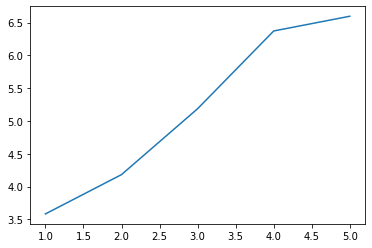

In [40]:
plt.plot(range(1,6),mse)
plt.show()

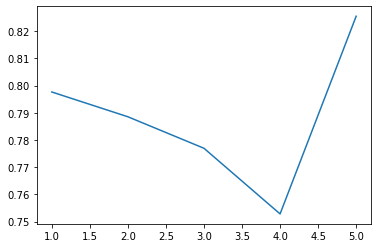

In [41]:
plt.plot(range(1,6),r2)
plt.show()